# Identify distinct customer segments 

## Importing Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [32]:
with open('census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f.readlines() if line.strip()]

df = pd.read_csv('census-bureau.data', header=None, names=columns)
y = df['label']
w = df['weight']

df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [33]:
columns_to_include = [
    # Demographics
    'age',                              
    'sex',                             
    'marital stat',                    
    'detailed household and family stat', 
    'family members under 18',         
    'race',                          
    'country of birth self',        
    'citizenship',   

    # geographic
    'region of previous residence',
    'state of previous residence',
    'migration code-change in msa',
    'migration code-change in reg',
    'migration code-move within reg',
    'migration prev res in sunbelt',
    'live in this house 1 year ago', 

    # behavioral
    'weeks worked in year',
    'full or part time employment stat',
    'class of worker',
    'own business or self employed',
    'member of a labor union',
    'capital gains',
    'capital losses',
    'dividends from stocks',
    'enroll in edu inst last wk'
]

In [34]:
missing_counts = df.replace('?', np.nan).isnull().sum().sort_values(ascending=False)
missing_counts.head(10)

migration code-change in msa      99696
migration code-change in reg      99696
migration code-move within reg    99696
migration prev res in sunbelt     99696
country of birth father            6713
country of birth mother            6119
country of birth self              3393
hispanic origin                     874
state of previous residence         708
citizenship                           0
dtype: int64

In [35]:
columns_to_drop = [
    # High missing (51%)
    'migration code-change in msa',
    'migration code-change in reg',
    'migration code-move within reg',
    'migration prev res in sunbelt',
    
    # Not very useful
    'country of birth father',
    'country of birth mother',

    # have stronger demographic features than these
    'hispanic origin',
    'state of previous residence',

    'label',  # Target
    'weight',  # Sampling weight
    'year',  # No variance
    'tax filer stat',  # Leakage
    'race',  # Ethical
    'country of birth self',  # Not critical
    'region of previous residence',  # Geographic, not needed
    'live in this house 1 year ago',  # Not critical
    'detailed industry recode',  # Too granular
    'detailed occupation recode',  # Too granular
    'detailed household summary in household',  # Redundant
    'wage per hour',  # Too sparse
    'capital gains',  # Too sparse
    'capital losses',  # Too sparse
    'dividends from stocks',  # Too sparse
    'num persons worked for employer',  # Not meaningful
    'reason for unemployment',  # Sparse
    'fill inc questionnaire for veteran\'s admin',  # Administrative
    'veterans benefits'  # Sparse
]

df.drop(columns=columns_to_drop, inplace=True)

In [36]:
categorical_cols = df.select_dtypes(include=['object']).columns

numerical_cols = df.columns[~df.columns.isin(categorical_cols)].tolist()

# Exploratory Data Analysis

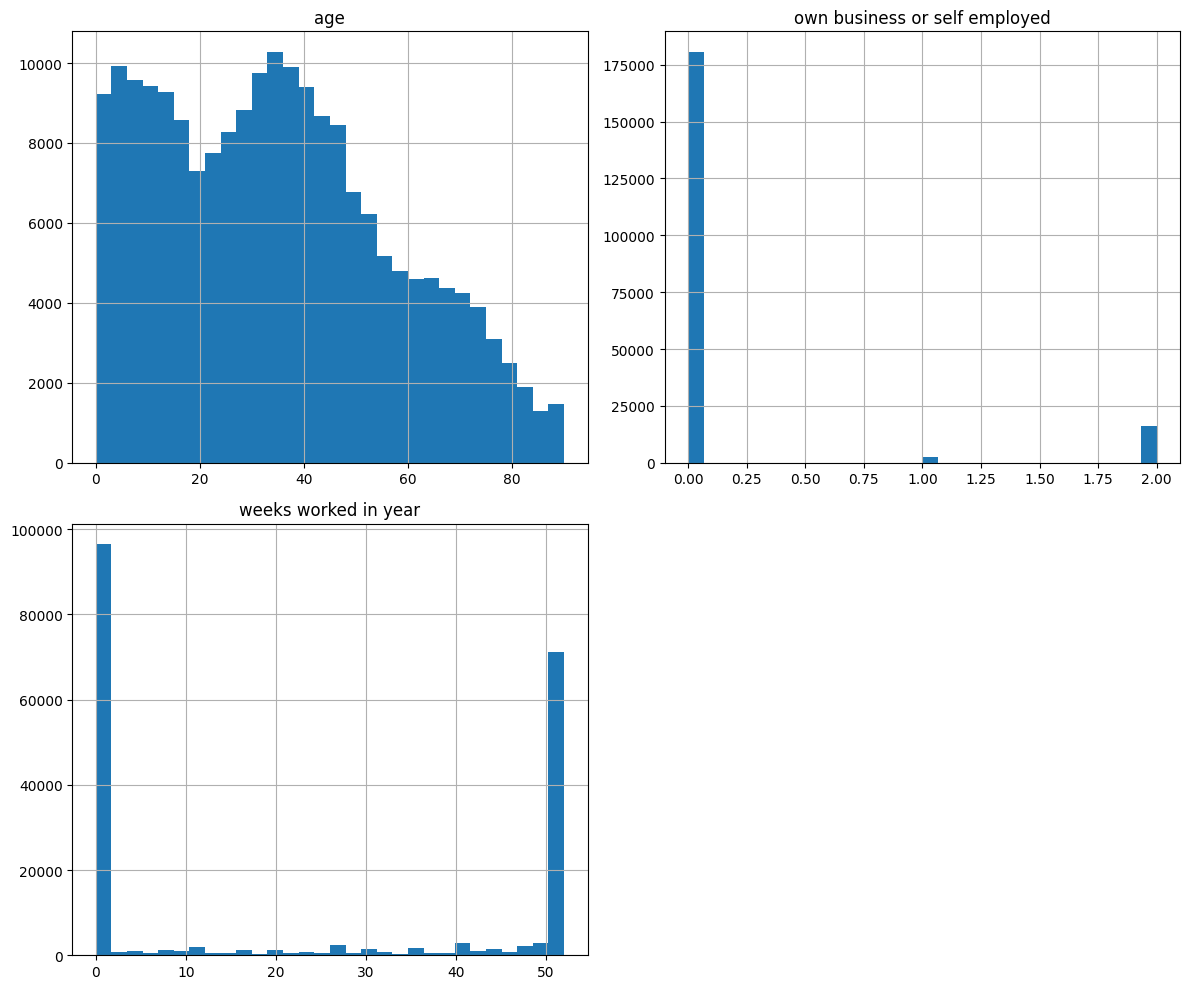

In [37]:
df[numerical_cols].hist(bins=30, figsize=(12, 10))
plt.tight_layout()
plt.show()

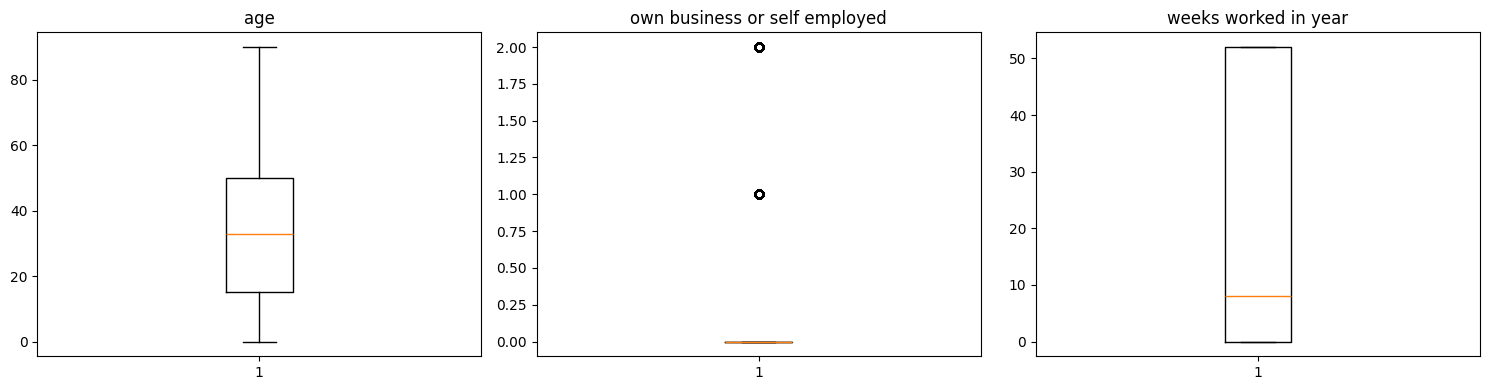

In [38]:
n = len(numerical_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

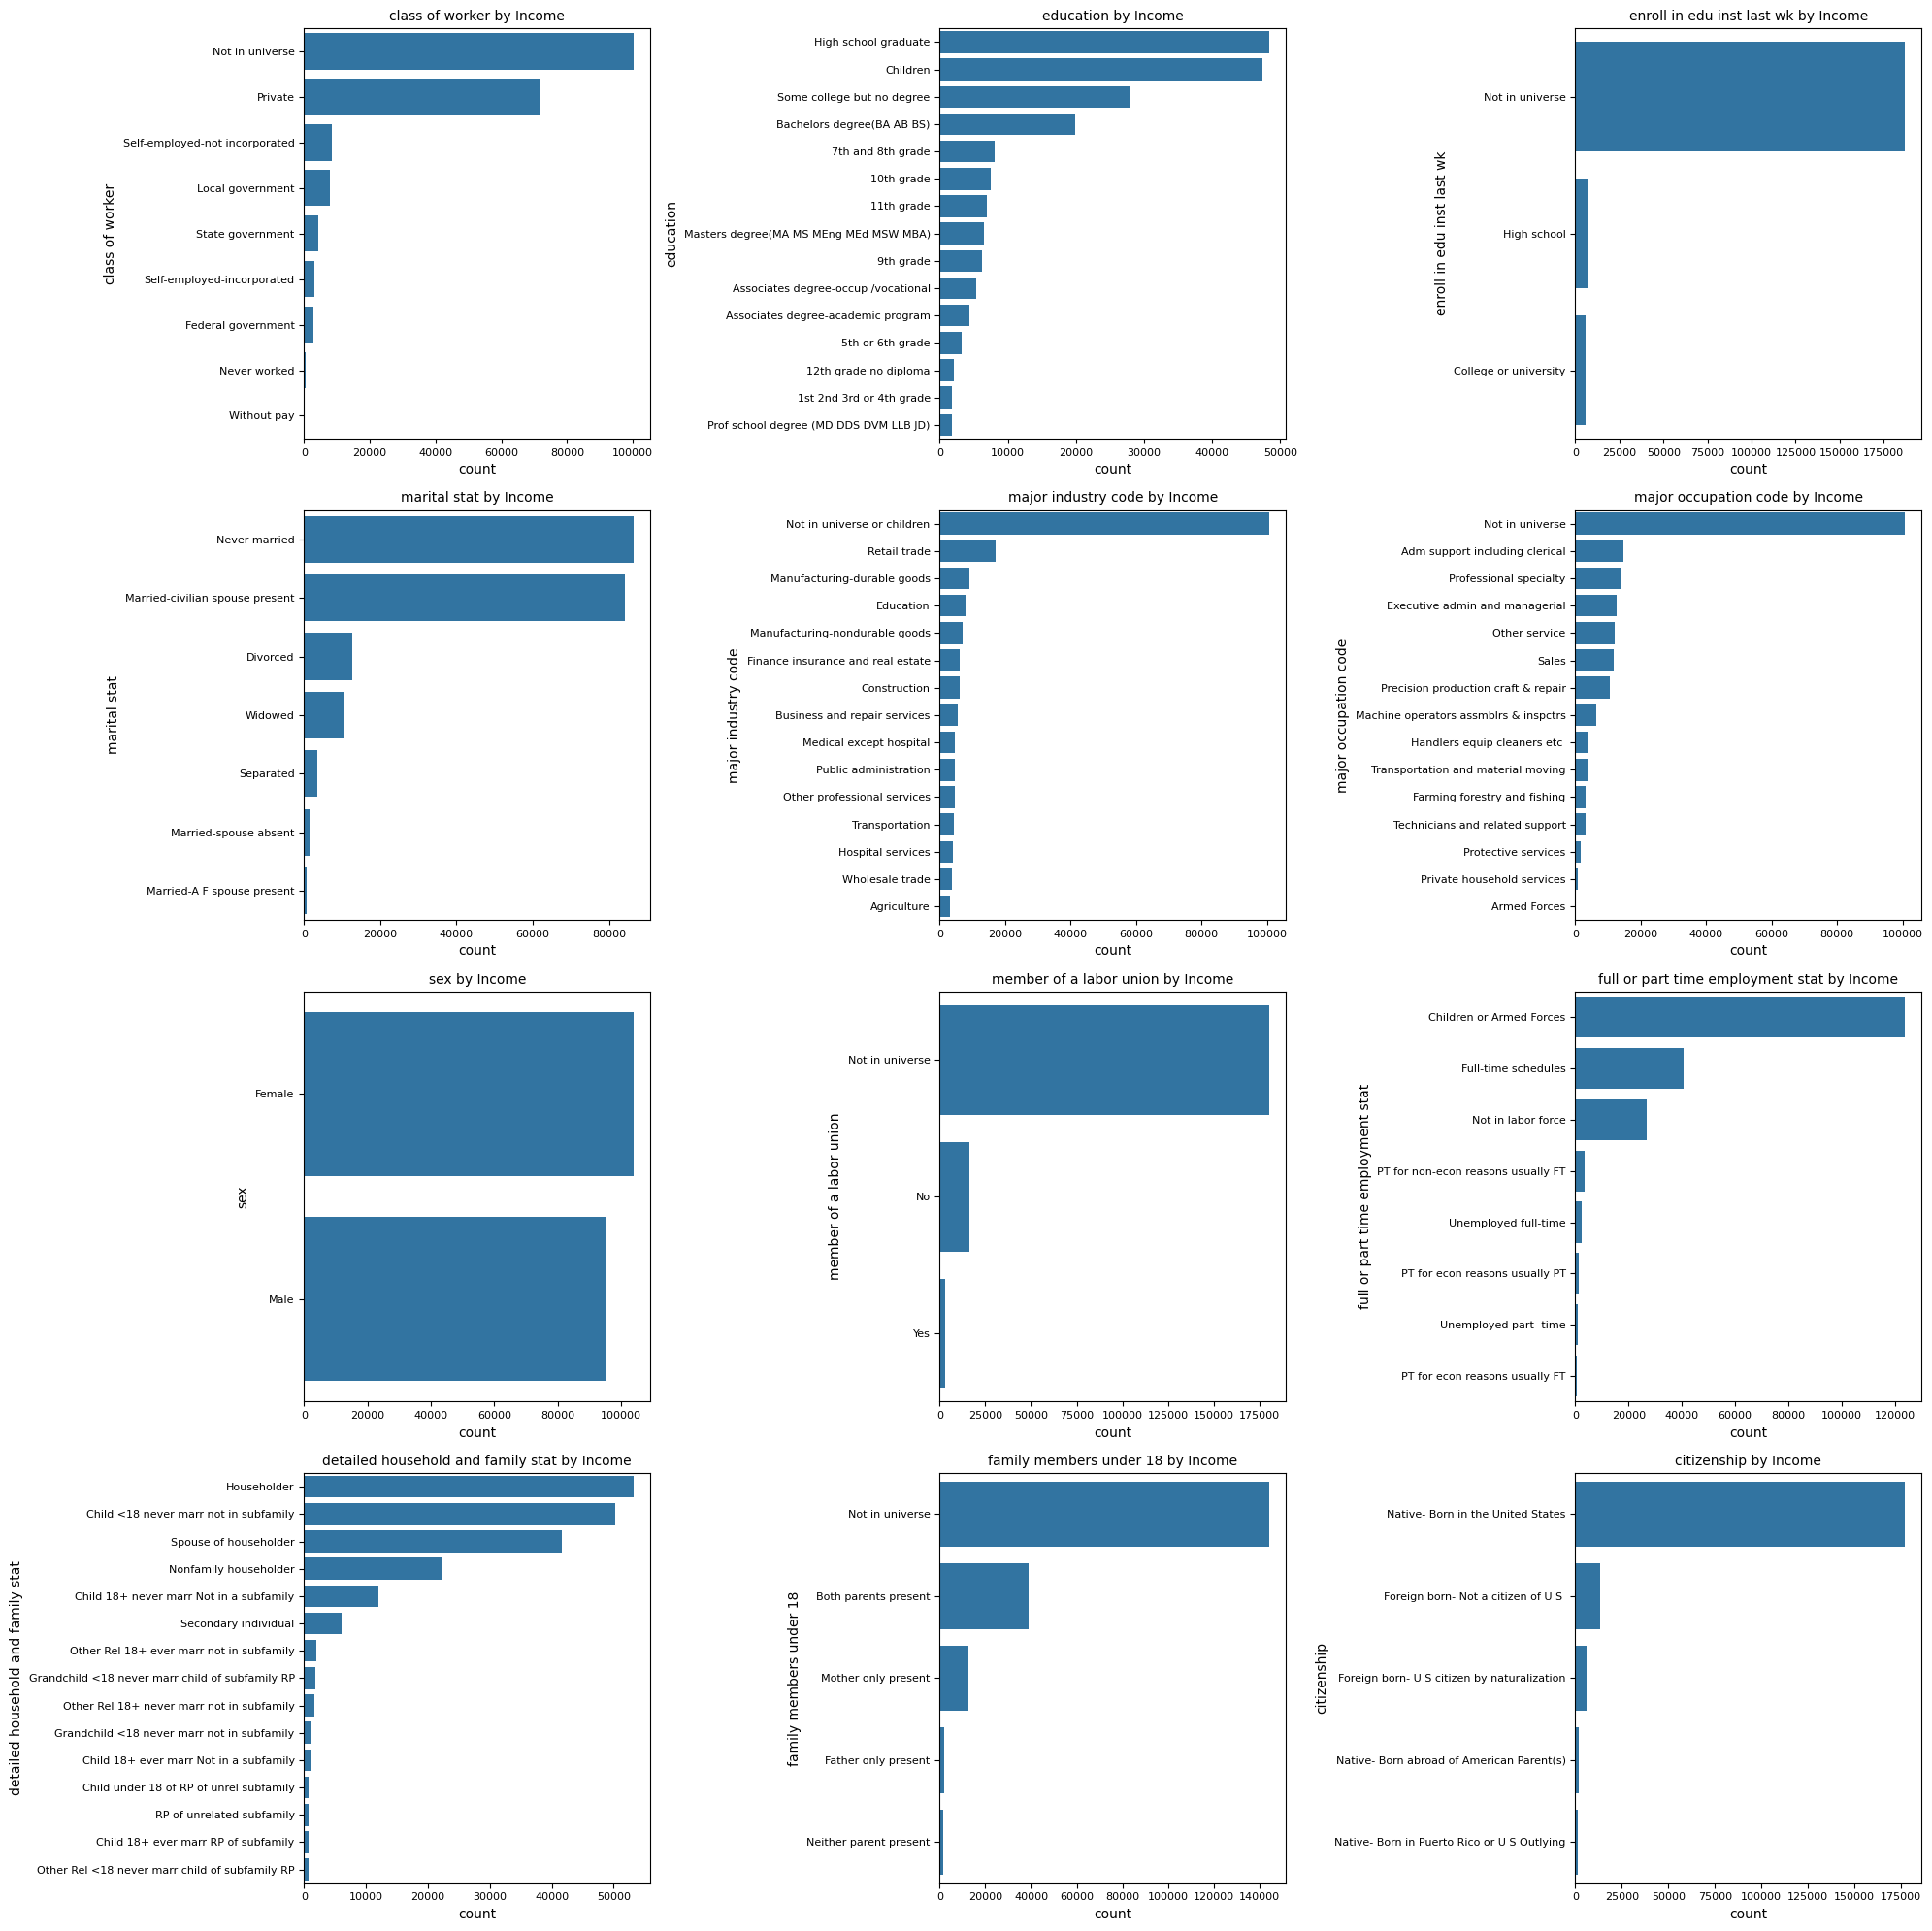

In [39]:
n_features = len(categorical_cols)
n_cols = 3  
n_rows = math.ceil(n_features / n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df, y=col, ax=axes[idx], 
                  order=df[col].value_counts().index[:15])  
    axes[idx].set_title(f'{col} by Income', fontsize=10)
    axes[idx].tick_params(labelsize=8)

for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])
    
plt.tight_layout()
plt.show()

In [40]:
# features with high imbalance

imbalance_cols = [
    'enroll in edu inst last wk',  # 95%+ Not in universe
    'member of a labor union',     # 90%+ Not in universe
]

df.drop(columns=imbalance_cols, inplace=True)

In [41]:
categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.columns[~df.columns.isin(categorical_cols)].tolist()

In [42]:
df_preprocessed = pd.read_csv('census_processed.csv')

In [43]:
columns_from_processed = [
    # Demographics
    'age',
    'sex',
    'marital_category',
    'household_role',
    
    # Employment
    'education_tier',
    'occupation_tier',
    'industry_pay_level',
    'weeks worked in year',
    'works_full_year',
    'worker_class_simple',

]

df = df_preprocessed[columns_from_processed].copy()

In [44]:
# Numerical features that need scaling
numerical_to_scale = [
    'age',                   
    'weeks worked in year'   
]

# Binary feature
binary_features = [
    'works_full_year' 
]

# Categorical features 
categorical_features = df.columns[~df.columns.isin(numeric_cols + binary_features)]

# Modeling

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_to_scale),
        ('binary', 'passthrough', binary_features),  
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

X_scaled = preprocessor.fit_transform(df)

### KMeans clustering

In [46]:
np.random.seed(42)
sample_size = 50000
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

print("Using sample of", sample_size, "for elbow method")

inertias = []
silhouette_scores = []
K_range = range(2, 8)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_sample, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print("K =", k, "| Inertia:", int(kmeans.inertia_), "| Silhouette:", round(sil_score, 3))

Using sample of 50000 for elbow method
K = 2 | Inertia: 186263 | Silhouette: 0.345
K = 3 | Inertia: 141669 | Silhouette: 0.373
K = 4 | Inertia: 130268 | Silhouette: 0.307
K = 5 | Inertia: 121501 | Silhouette: 0.308
K = 6 | Inertia: 114672 | Silhouette: 0.316
K = 7 | Inertia: 108374 | Silhouette: 0.272


Using a random sample of 50,000 observations provides a computationally efficient yet statistically representative view of the population, allowing reliable identification of the optimal number of clusters without materially affecting the elbow or silhouette patterns.

In this case, K = 3 shows the highest silhouette score and a clear slowdown in inertia reduction, suggesting it is the most appropriate number of clusters for segmentation.

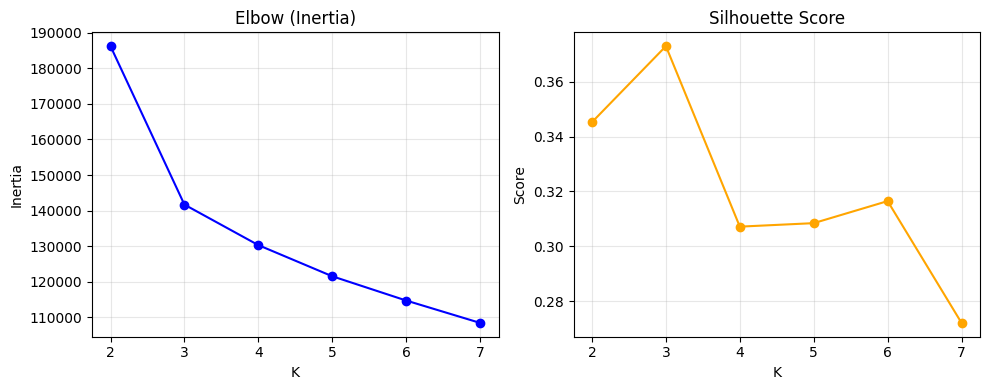

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(K_range, inertias, marker='o', color='blue')
ax1.set(title='Elbow (Inertia)', xlabel='K', ylabel='Inertia')
ax1.grid(alpha=0.3)

ax2.plot(K_range, silhouette_scores, marker='o', color='orange')
ax2.set(title='Silhouette Score', xlabel='K', ylabel='Score')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Builidng final model

In [48]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

clusters = kmeans_final.labels_

df['cluster'] = clusters

print(df['cluster'].value_counts().sort_index())

cluster
0    39772
1    57939
2    97904
Name: count, dtype: int64


In [49]:
df.head()

,age,sex,marital_category,household_role,education_tier,occupation_tier,industry_pay_level,weeks worked in year,works_full_year,worker_class_simple,cluster
0,73,Female,Previously_married,Other_Relative,High_School,Not_Working,Not_Working,0,0,Not_Working,0
1,58,Male,Previously_married,Householder,Some_College,Low_Skill,Mid_Pay,52,1,Self_Employed,2
2,18,Female,Never_married,Child,Less_than_HS,Not_Working,Not_Working,0,0,Not_Working,1
3,9,Female,Never_married,Child,Child,Not_Working,Not_Working,0,0,Not_Working,1
4,10,Female,Never_married,Child,Child,Not_Working,Not_Working,0,0,Not_Working,1


## Cluster Description


In [50]:
df['label'] = y
df['weight'] = w

The clustering model segments the population into distinct socio-economic groups that differ meaningfully in age, employment stability, and income potential.
This allows the retail client to move from blanket marketing to targeted, high-ROI campaigns tailored to each segment’s purchasing power and needs.

While the proportion of high-income individuals is similar across segments, the working-age segment represents the majority of economically active consumers, with significantly higher workforce participation and employment consistency.

## Cluster size distribution

In [51]:
cluster_names = {
    0: "Fixed Income Retirees",
    1: "Future Customers", 
    2: "Prime Banking Customers"
}

cluster_sizes = df['cluster'].value_counts().sort_index()

for cluster_id, count in cluster_sizes.items():
    print(f"Cluster {cluster_id} ({cluster_names[cluster_id]}): {count:,} ({count/len(df)*100:.2f}%)")

print(f"\nTotal: {len(df):,}")

Cluster 0 (Fixed Income Retirees): 39,772 (20.33%)
Cluster 1 (Future Customers): 57,939 (29.62%)
Cluster 2 (Prime Banking Customers): 97,904 (50.05%)

Total: 195,615


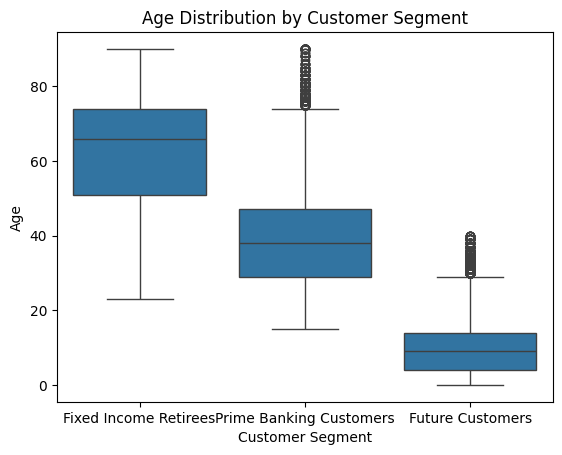

In [52]:
sns.boxplot(
    data=df,
    x=df["cluster"].replace(cluster_names),
    y="age"
)
plt.title("Age Distribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Age")
plt.show()


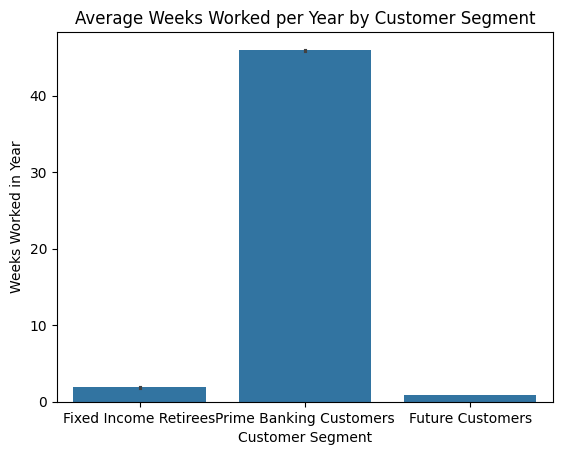

In [53]:
sns.barplot(
    data=df,
    x=df["cluster"].replace(cluster_names),
    y="weeks worked in year"
)
plt.title("Average Weeks Worked per Year by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Weeks Worked in Year")
plt.show()

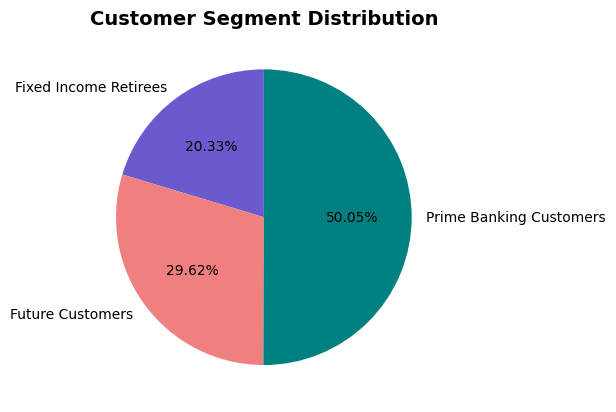

In [54]:
labels = [cluster_names[i] for i in range(3)]

plt.pie(cluster_sizes, 
        labels=labels,
        autopct='%1.2f%%',
        startangle=90,
        colors=["slateblue", "lightcoral", "teal"]


)

plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.show()

## Demographic Profile

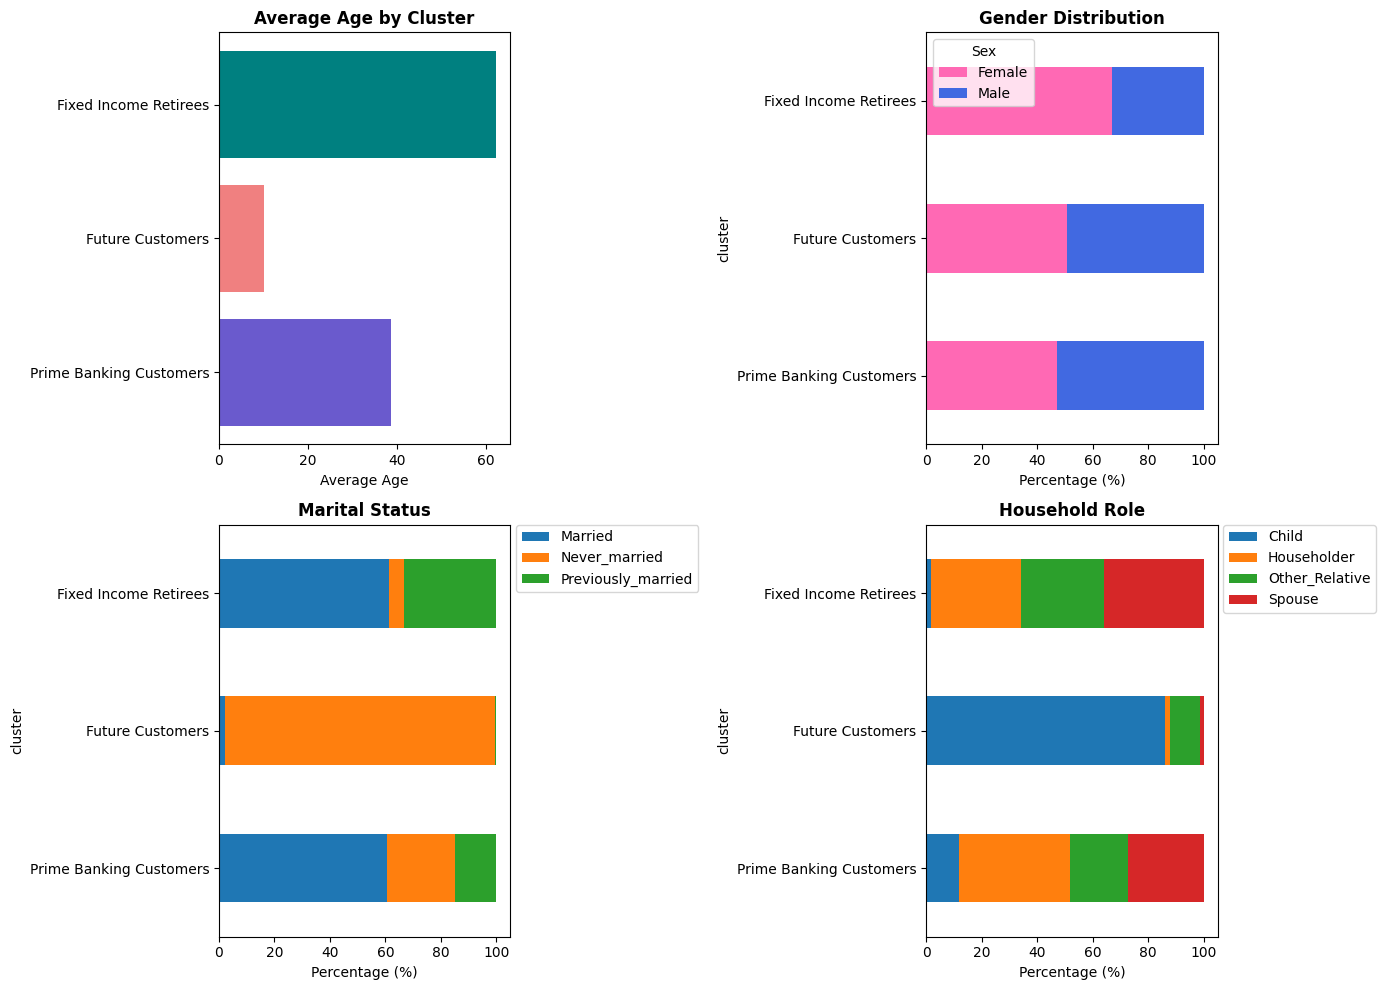

In [55]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

colors = ["slateblue", "lightcoral", "teal"]
labels = [cluster_names[2], cluster_names[1], cluster_names[0]]
cluster_order = [2, 1, 0]

# age distribution
age_avg = df.groupby('cluster')['age'].mean().reindex(cluster_order)
ax1.barh(range(len(cluster_order)), age_avg, color=colors)
ax1.set(
    yticks=range(len(cluster_order)),
    yticklabels=labels,
    xlabel="Average Age",
    title="Average Age by Cluster"
)
ax1.title.set_fontweight("bold")

# gender distribution
gender_dist = (
    pd.crosstab(df["cluster"], df["sex"], normalize="index")
      .mul(100)
      .reindex(cluster_order)
)
gender_dist.plot(kind="barh", ax=ax2, stacked=True, color=["hotpink", "royalblue"])
ax2.set(
    yticks=range(len(cluster_order)),
    yticklabels=labels,
    xlabel="Percentage (%)",
    title="Gender Distribution"
)
ax2.title.set_fontweight("bold")
ax2.legend(title="Sex", loc="best")

# marital status
marital_dist = (
    pd.crosstab(df["cluster"], df["marital_category"], normalize="index")
      .mul(100)
      .reindex(cluster_order)
)
marital_dist.plot(kind="barh", ax=ax3, stacked=True)
ax3.set(
    yticks=range(len(cluster_order)),
    yticklabels=labels,
    xlabel="Percentage (%)",
    title="Marital Status"
)
ax3.title.set_fontweight("bold")
ax3.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

# household role
household_dist = (
    pd.crosstab(df["cluster"], df["household_role"], normalize="index")
      .mul(100)
      .reindex(cluster_order)
)
household_dist.plot(kind="barh", ax=ax4, stacked=True)
ax4.set(
    yticks=range(len(cluster_order)),
    yticklabels=labels,
    xlabel="Percentage (%)",
    title="Household Role"
)
ax4.title.set_fontweight("bold")
ax4.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

## Socioeconomic Profile

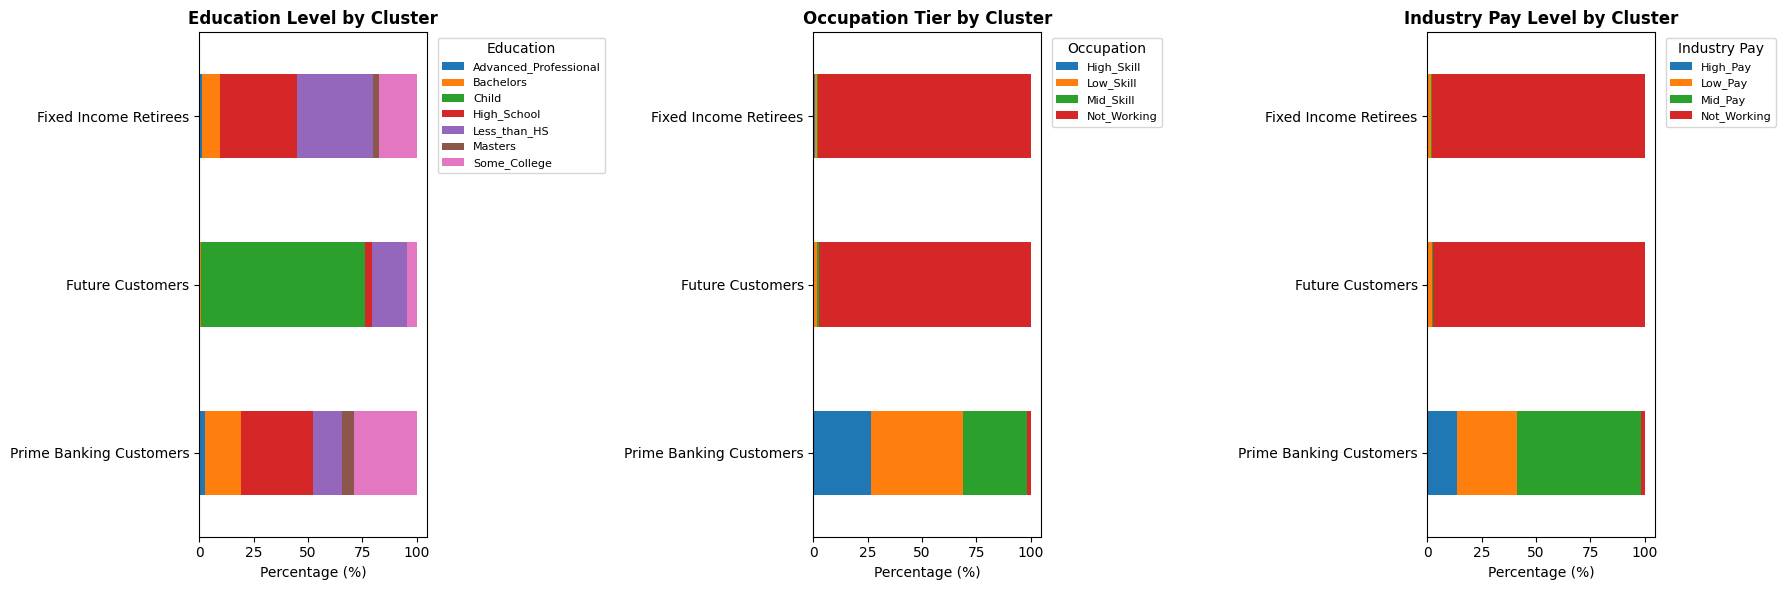

In [56]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

labels = [cluster_names[2], cluster_names[1], cluster_names[0]]
cluster_order = [2, 1, 0]
y = range(len(cluster_order))

# Education Level
education_dist = (
    pd.crosstab(df["cluster"], df["education_tier"], normalize="index")
      .mul(100)
      .reindex(cluster_order)
)
education_dist.plot(kind="barh", stacked=True, ax=ax1)
ax1.set(
    title="Education Level by Cluster",
    xlabel="Percentage (%)",
    ylabel="",
    yticks=y,
    yticklabels=labels
)
ax1.title.set_fontweight("bold")
ax1.legend(title="Education", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

# Occupation Tier
occupation_dist = (
    pd.crosstab(df["cluster"], df["occupation_tier"], normalize="index")
      .mul(100)
      .reindex(cluster_order)
)
occupation_dist.plot(kind="barh", stacked=True, ax=ax2)
ax2.set(
    title="Occupation Tier by Cluster",
    xlabel="Percentage (%)",
    ylabel="",
    yticks=y,
    yticklabels=labels
)
ax2.title.set_fontweight("bold")
ax2.legend(title="Occupation", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

# Industry Pay Level
industry_dist = (
    pd.crosstab(df["cluster"], df["industry_pay_level"], normalize="index")
      .mul(100)
      .reindex(cluster_order)
)
industry_dist.plot(kind="barh", stacked=True, ax=ax3)
ax3.set(
    title="Industry Pay Level by Cluster",
    xlabel="Percentage (%)",
    ylabel="",
    yticks=y,
    yticklabels=labels
)
ax3.title.set_fontweight("bold")
ax3.legend(title="Industry Pay", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

## Employment patterns

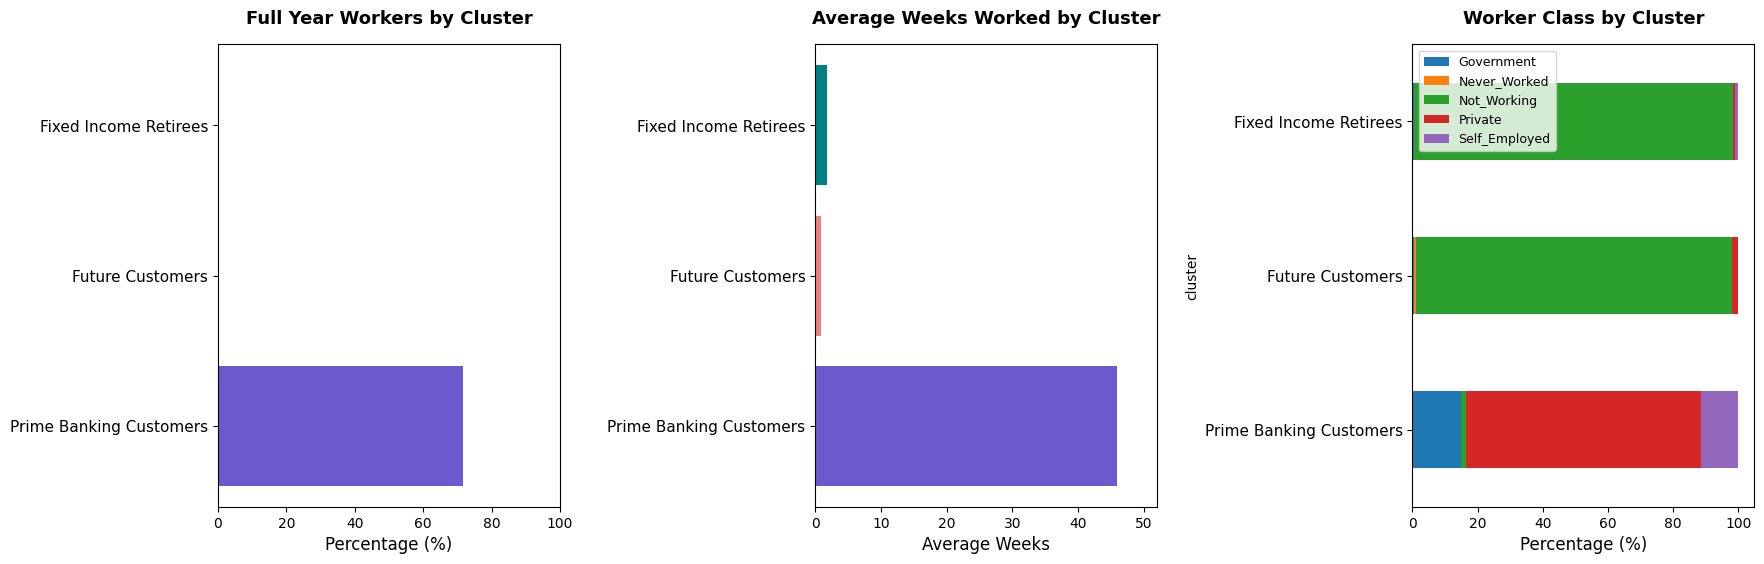

In [57]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

colors = ["slateblue", "lightcoral", "teal"] 
labels = [cluster_names[2], cluster_names[1], cluster_names[0]]
cluster_order = [2, 1, 0]

# Full Year Workers
full_year = (df.groupby('cluster')['works_full_year'].mean() * 100).reindex(cluster_order)

y = range(3)
ax1.barh(y, full_year, color=colors)
ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=11)
ax1.set_xlabel('Percentage (%)', fontsize=12)
ax1.set_title('Full Year Workers by Cluster', fontweight='bold', fontsize=13, pad=15)
ax1.set_xlim(0, 100)

# Average Weeks Worked 
weeks_worked = df.groupby('cluster')['weeks worked in year'].mean().reindex(cluster_order)

ax2.barh(y, weeks_worked, color=colors)
ax2.set_yticks(y)
ax2.set_yticklabels(labels, fontsize=11)
ax2.set_xlabel('Average Weeks', fontsize=12)
ax2.set_title('Average Weeks Worked by Cluster', fontweight='bold', fontsize=13, pad=15)
ax2.set_xlim(0, 52)


# Worker Class Distribution 
worker_class_dist = (
    pd.crosstab(df['cluster'], df['worker_class_simple'], normalize='index') * 100
).reindex(cluster_order)

worker_class_dist.plot(kind='barh', stacked=True, ax=ax3)
ax3.set_yticks(y)
ax3.set_yticklabels(labels, fontsize=11)
ax3.set_xlabel('Percentage (%)', fontsize=12)
ax3.set_title('Worker Class by Cluster', fontweight='bold', fontsize=13, pad=15)
ax3.legend(loc='best', fontsize=9)

plt.tight_layout(pad=2.0)
plt.show()

## Understanding Segments

In [58]:
print("Segment Overview:")

for cluster_id in [2, 1, 0]:
    cluster_data = df[df['cluster'] == cluster_id]
    size = len(cluster_data)
    pct = size / len(df) * 100
    avg_age = cluster_data['age'].mean()
    employment = cluster_data['works_full_year'].mean() * 100
    
    print("\n{}:".format(cluster_names[cluster_id]))
    print("  • Size: {:,} customers ({:.1f}% of market)".format(size, pct))
    print("  • Average Age: {:.0f} years".format(avg_age))
    print("  • Employment Rate: {:.1f}%".format(employment))


Segment Overview:

Prime Banking Customers:
  • Size: 97,904 customers (50.0% of market)
  • Average Age: 39 years
  • Employment Rate: 71.6%

Future Customers:
  • Size: 57,939 customers (29.6% of market)
  • Average Age: 10 years
  • Employment Rate: 0.1%

Fixed Income Retirees:
  • Size: 39,772 customers (20.3% of market)
  • Average Age: 62 years
  • Employment Rate: 0.5%


## Budget Allocation for Marketing

One-size-fits-all marketing wastes money on mismatched audiences.
Targeted approach increases conversion and reduces customer acquisition cost.

In [59]:
print("Marketing Budget Allocation")

weights = {"size": 0.30, "weeks": 0.50, "income": 0.20}
total_priority = 0
priority_scores = []

for cluster_id in [2, 1, 0]:
    cluster_data = df[df["cluster"] == cluster_id]

    size_pct = (len(cluster_data) / len(df)) * 100
    weeks_worked = cluster_data["weeks worked in year"].mean()
    weeks_norm = (weeks_worked / 52) * 100
    high_income_pct = (cluster_data["label"] == "50000+.").mean() * 100

    priority = (
        size_pct * weights["size"]
        + weeks_norm * weights["weeks"]
        + high_income_pct * weights["income"]
    )

    priority_scores.append(priority)
    total_priority += priority

    lines = [
        "\n" + cluster_names[cluster_id] + ":",
        "  Market Size: " + format(size_pct, ".1f") + "% (weight: " + format(weights["size"], ".2f") + ")",
        "  Avg Weeks Worked: " + format(weeks_worked, ".1f") + "/52 = " + format(weeks_norm, ".1f") + "% (weight: " + format(weights["weeks"], ".2f") + ")",
        "  High Income %: " + format(high_income_pct, ".1f") + "% (weight: " + format(weights["income"], ".2f") + ")",
        "  Priority Score: " + format(priority, ".2f"),
    ]

    print("\n".join(lines))

print("\n")
for i, score in enumerate(priority_scores):
    print(cluster_names[i] + ": " + format(score / total_priority, ".2f"))


Marketing Budget Allocation

Prime Banking Customers:
  Market Size: 50.0% (weight: 0.30)
  Avg Weeks Worked: 45.9/52 = 88.3% (weight: 0.50)
  High Income %: 6.3% (weight: 0.20)
  Priority Score: 60.44

Future Customers:
  Market Size: 29.6% (weight: 0.30)
  Avg Weeks Worked: 0.9/52 = 1.7% (weight: 0.50)
  High Income %: 6.1% (weight: 0.20)
  Priority Score: 10.98

Fixed Income Retirees:
  Market Size: 20.3% (weight: 0.30)
  Avg Weeks Worked: 1.9/52 = 3.6% (weight: 0.50)
  High Income %: 6.1% (weight: 0.20)
  Priority Score: 9.11


Fixed Income Retirees: 0.75
Future Customers: 0.14
Prime Banking Customers: 0.11


I adjusted from raw scores (75-14-11) to strategic allocation (60-25-15) because Fixed Income's asset-based value isn't captured by activity metrics, and Prime Banking faces diminishing returns beyond 60%

Prime Banking Customers (60%): Highest transaction volume and strongest short-term revenue impact, making them the top priority for marketing spend.

Fixed Income Retirees (25%): Stable and loyal segment with accumulated assets, justifying sustained but moderate investment.

Future Customers (15%): Lower immediate returns but significant long-term growth potential, suitable for early engagement and lifecycle marketing.

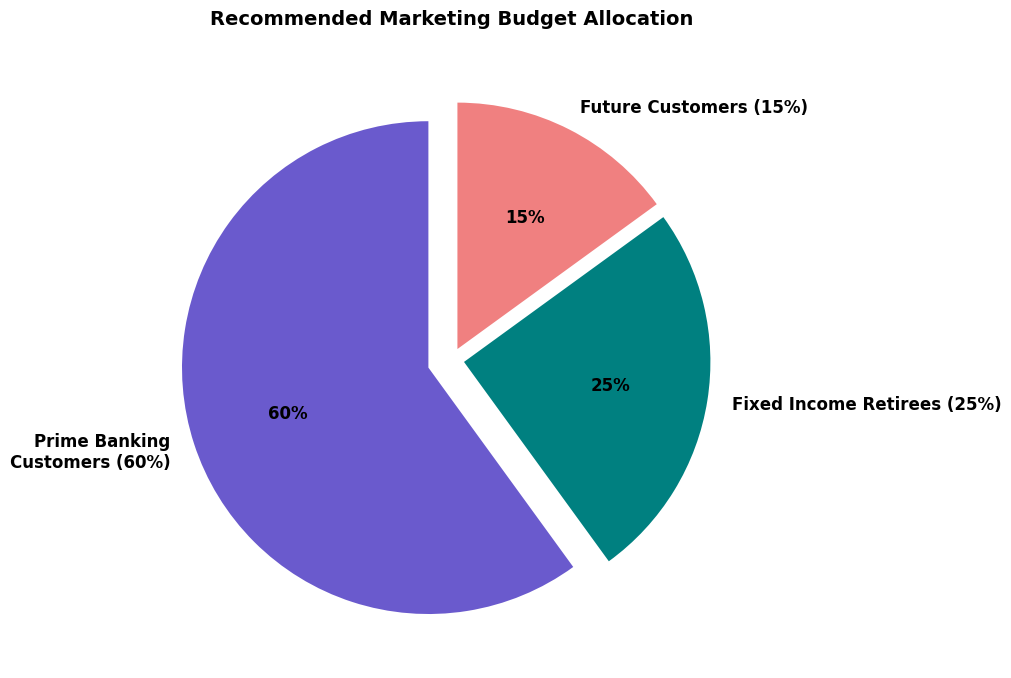

In [60]:
# Budget Allocation Pie Chart
fig, ax = plt.subplots(figsize=(10, 8))

budget_allocation = [60, 25, 15]
labels = ['Prime Banking\nCustomers (60%)', 
          'Fixed Income Retirees (25%)', 
          'Future Customers (15%)']
colors = ["slateblue", "teal", "lightcoral"] 
explode = (0.1, 0.05, 0.05)  

plt.pie(budget_allocation, 
        labels=labels,
        colors=colors,
        autopct='%1.0f%%',
        startangle=90,
        explode=explode,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Recommended Marketing Budget Allocation', fontsize=14, fontweight='bold', pad=20)
plt.show()

I don't have empirical data on the exact diminishing returns threshold. However, allocating 75% to a single segment creates concentration risk. 60% still prioritizes Prime Banking as our highest-ROI segment while maintaining strategic diversification. The exact threshold would need to be validated through A/B testing and historical campaign data

# References
https://www.analyticsvidhya.com/blog/2021/06/how-to-solve-customer-segmentation-problem-with-machine-learning/

https://openviewpartners.com/blog/customer-segmentation/

https://improvado.io/blog/marketing-budget-allocation

https://visbanking.com/customer-segmentation-in-banking